# DMSP-OLS / VIIRS-DNB Harmonizer — Mini-Tutorial

**Audience.** Senior data scientist comfortable with Python, ML, and
raster geospatial work, but new to nighttime lights (NTL) and the
specific literature on cross-platform harmonization.

**Goal.** Walk through the WB-LEN harmonizer pipeline end to end on a
small region (Paris, ~1°×1°), explaining the math, key assumptions, and
design decisions at each stage. Plots at each stage make the data
concrete; references at the bottom point to the foundational literature.

**What we won't cover.** Architecture trade-offs that the legacy version
made (e.g. annual composites, manual downloads) — see the repo `README.md`
for the migration narrative.

**Runtime.** ~3–5 minutes end to end against the public
`s3://globalnightlight/` bucket (no authentication required).

---

## 1. Background: nighttime lights as a remote sensing dataset

**Why NTL?** Spaceborne measurements of light emitted from the Earth's
surface at night correlate strongly with human presence, energy use, and
economic activity. They've been used as proxies for GDP at sub-national
scales (Henderson, Storeygard, Weil 2012), to detect rural
electrification (Min et al. 2013), and to track urbanization, conflict,
and disaster recovery.

**The two instruments we care about.**

| Sensor | Period | Native res. | Encoding | Notes |
|---|---|---|---|---|
| **DMSP-OLS** | 1992–2013 (LEN extends through 2017) | 30 arc-sec (~1 km) | uint8 DN, 0–63 | Onboard amplification with thermal feedback; saturates over urban cores; the same physical light produces different DN values across satellites and across years. |
| **VIIRS-DNB** | 2012–present | 15 arc-sec (~500 m) | float32 radiance (nW/cm²/sr) | Calibrated radiometric signal, much wider dynamic range; sensitive to dim lights and lunar contamination. |

**Why harmonize?** A meaningful long time series (1992–present) needs
both sensors. But the two record fundamentally different signals on
different scales, and even within the DMSP era there's substantial
satellite-to-satellite drift. Harmonization is the procedure that maps
VIIRS-DNB onto a DMSP-DN-like scale and intercalibrates the DMSP
satellites to a common reference, producing a single coherent series.

Two well-cited references to anchor the literature:
- Elvidge et al. 2017 — VIIRS-DNB overview and applications
  (*International Journal of Remote Sensing* 38(21), 5860–5879).
- Li et al. 2017 — the DMSP intercalibration recipe this codebase uses
  (*Remote Sensing* 9(6), 637).

---

## 2. The data: World Bank Light Every Night (LEN)

WB-LEN is a public S3 archive at `s3://globalnightlight/` (anonymous
access, no auth) hosting **nightly orbit COGs** for both sensors, plus
STAC catalogs for discovery. This is qualitatively different from the
EOG/NOAA *annual composites* that older NTL workflows used: we now
have the per-orbit raw observations, with the per-pixel auxiliary
layers needed to do our own masking and compositing.

**Per-orbit layer bundle** (only the three we use):

| Layer | DMSP filename | VIIRS filename | Units | NoData |
|---|---|---|---|---|
| Radiance | `*.OIS.vis.co.tif` (uint8 DN) | `SVDNB_*.rade9.co.tif` (float32) | DN 0–63 / nW·cm⁻²·sr⁻¹ | sentinel (e.g. 255 / -999.3) |
| Lunar illuminance | `*.OIS.li.co.tif` | `GDNBO_*.li.co.tif` | lux | -1.0 / -999.3 |
| QA flag bitfield | `*.OIS.flag.co.tif` (uint16) | `*.vflag.co.tif` (uint32) | bit-packed | (none) |

Two important conventions:

1. **Lunar illuminance is a confounder** at the pixel level — VIIRS-DNB
   in particular detects moonlight scattered through the atmosphere as
   apparent surface brightness. The *Earth Observation Group* convention
   used to build their published composites is to keep only pixels
   acquired under effectively zero moonlight (a specific bit in the QA
   flag layer). We reproduce that convention as the default mask mode.
2. **The two sensors use different bit positions** for the zero-LI flag:
   bit 11 for DMSP, bit 5 for VIIRS. The `harmonizer.constants` module
   centralizes these so nothing else in the pipeline has to know.

---

## 3. Pipeline overview

The harmonizer is six chained stages. Each stage caches its output, so
reruns are incremental.

```
  s3://globalnightlight/
          │
          ▼
  [1. ingest]    STAC walk → windowed COG reads per orbit
          │
          ▼
  [2. orbitprep] mask (lunar bit + validity) + warp to ROI grid
          │
          ▼
  [3. composite] median over orbits within a period (default: monthly)
          │
          ▼
  [4. calibrate] DMSPstepwise (Li 2017) on DMSP / VIIRSprep on VIIRS
          │
          ▼
  [5. fit]       train Harmonizer on the overlap year's monthly stack
          │
          ▼
  [6. transform] apply to every VIIRS period → harmonized DN raster
```

We'll execute each stage manually in the cells below on a single ROI
(Paris, ~1°×1°) over a few days near new moon (Feb 2013), then show
the diagnostics that drop out of the full `main.py` pipeline.

---

## 4. Setup

Make sure you've installed the package (`pip install -e .` from the
repo root) and have set `NLT` to the parent dir holding the repo. The
cells below use a tight Paris bbox and a short date window so the demo
completes in a couple of minutes.

In [2]:
import logging
import os
import sys
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

# If running in-place from the repo without a pip-install, uncomment:
sys.path.insert(0, str(Path.cwd().parent))

from harmonizer.constants import (
    SENSOR_DMSP, SENSOR_VIIRS, SENSOR_CONFIGS,
    OLS_ZERO_LUNAR_ILLUM_BIT, VIIRS_ZERO_LUNAR_ILLUM_BIT,
)
from harmonizer.ingest import STACCatalogClient, WindowedCOGReader, orbitref_from_item, ingest
from harmonizer.transformers.orbitprep import (
    OrbitPrep, decode_bit, make_lunar_mask, make_validity_mask,
)
from harmonizer.composite import Compositor
from harmonizer.calibrate import calibrate_dmsp_composites, prep_viirs_composites
from harmonizer.transformers.dmspcalibrate import DMSPstepwise, PUBLISHED_COEFS
from harmonizer.transformers.viirsprep import VIIRSprep
from harmonizer.transformers.harmonize import Harmonizer
from harmonizer.transformers.curve import CurveFit
from harmonizer.utils import get_kernel

logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')

PARIS_BBOX = (2.0, 48.5, 3.0, 49.5)
TUTORIAL_CACHE = Path(tempfile.gettempdir()) / 'harmonizer_tutorial'
TUTORIAL_CACHE.mkdir(exist_ok=True)

# Date window: Feb 8–12, 2013 — new moon was Feb 10, so zero-lunar masking
# will actually keep VIIRS data instead of dropping every orbit.
WINDOW_START = datetime(2013, 2, 8, tzinfo=timezone.utc)
WINDOW_END = datetime(2013, 2, 12, 23, 59, tzinfo=timezone.utc)
print(f'cache: {TUTORIAL_CACHE}')

cache: /tmp/harmonizer_tutorial


## 5. Stage 1 — Ingest

**What it does.** Walk the public STAC catalogs at
`https://globalnightlight.s3.amazonaws.com/{DMSP|VIIRS_npp}_catalog.json`,
find orbits whose bounding box intersects our ROI in the date range,
resolve each orbit's three-layer URL triplet (radiance / LI / flag), and
do a *windowed* COG read against each layer — fetching only the bytes
covering our ROI rather than the whole swath.

**Key design point.** COGs (Cloud Optimized GeoTIFFs) are tiled and
indexed so HTTP range reads can pull just the tiles intersecting an
ROI. The legacy harmonizer downloaded ~115 GB of full-globe annual
composites; this version pulls a few KB per orbit per layer instead.

**A small subtlety.** VIIRS' three layers are in three different STAC
items with different processing-timestamp suffixes, so the LI URL
can't be derived from the radiance URL by simple substitution; we
list-by-prefix to find the matching GDNBO file. DMSP's six-layer bundle
shares an orbit prefix and resolves directly. See `harmonizer.constants`
for the per-sensor name resolvers.

In [ ]:
# Walk the VIIRS catalog and grab the first orbit intersecting Paris.
client = STACCatalogClient(SENSOR_VIIRS)
items = list(client.find_items(PARIS_BBOX, WINDOW_START, WINDOW_END))
print(f'Found {len(items)} VIIRS orbits over Paris in this window')

orbit = orbitref_from_item(items[0], SENSOR_VIIRS)
print(f'orbit: {orbit.orbit_id}')
print(f'time:  {orbit.datetime}')
print(f'bbox:  {orbit.bbox}')
print(f'radiance: {orbit.radiance_url[-90:]}')

# WindowedCOGReader is bound to the ROI bbox at construction time so its
# cache key (sensor / roi-slug / period / orbit_id) cannot collide with a
# different-ROI run sharing the same cache_dir.
reader = WindowedCOGReader(TUTORIAL_CACHE / 'ingest', roi_bbox=PARIS_BBOX)
paths = {
    layer: reader.read_window(
        getattr(orbit, f'{layer}_url'),
        PARIS_BBOX,
        reader.cache_path(orbit, layer),
    )
    for layer in ('radiance', 'li', 'flag')
}
for layer, p in paths.items():
    print(f'  {layer:9s} -> {p.name}  ({p.stat().st_size/1024:.1f} KB)')


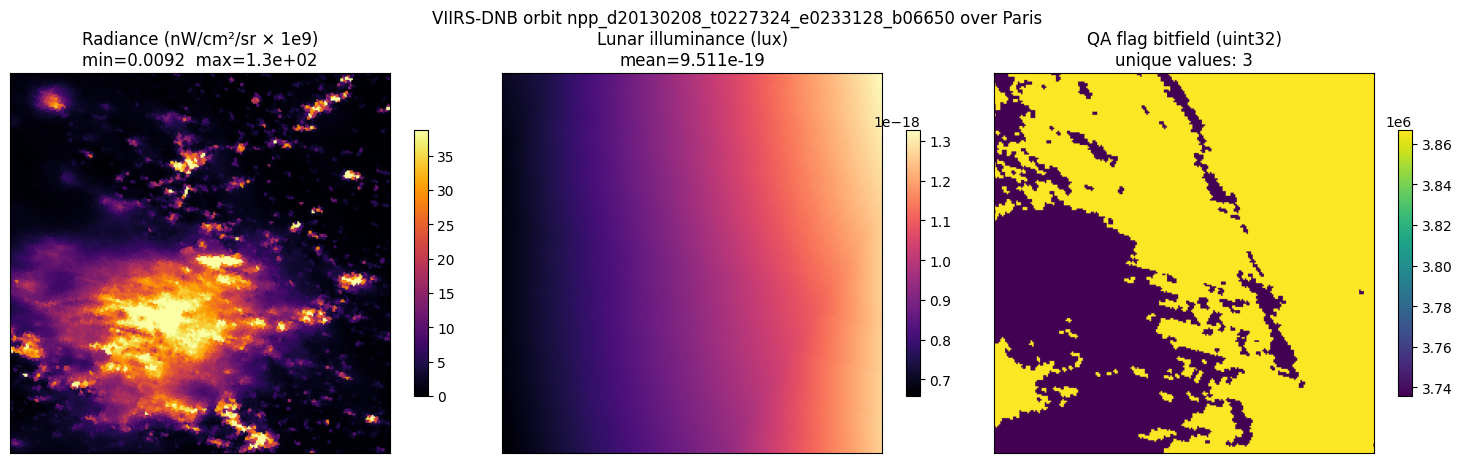

In [4]:
# Visualize the three co-located layers for this orbit.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
with rasterio.open(paths['radiance']) as src:
    rad = src.read(1)
with rasterio.open(paths['li']) as src:
    li = src.read(1)
with rasterio.open(paths['flag']) as src:
    flag = src.read(1)

im0 = axes[0].imshow(rad, cmap='inferno', vmin=0, vmax=np.quantile(rad[rad > 0], 0.98) if (rad > 0).any() else 1)
axes[0].set_title(f'Radiance (nW/cm²/sr × 1e9)\nmin={rad.min():.2g}  max={rad.max():.2g}')
plt.colorbar(im0, ax=axes[0], shrink=0.7)

im1 = axes[1].imshow(li, cmap='magma')
axes[1].set_title(f'Lunar illuminance (lux)\nmean={np.nanmean(li):.4g}')
plt.colorbar(im1, ax=axes[1], shrink=0.7)

im2 = axes[2].imshow(flag, cmap='viridis')
axes[2].set_title(f'QA flag bitfield (uint32)\nunique values: {len(np.unique(flag))}')
plt.colorbar(im2, ax=axes[2], shrink=0.7)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'VIIRS-DNB orbit {orbit.orbit_id} over Paris', y=1.02)
plt.tight_layout(); plt.show()

## 6. Stage 2 — Per-orbit cleaning (`OrbitPrep`)

**What it does.** Mask out moonlit and bad pixels, then warp the orbit
onto a per-sensor common ROI grid (DMSP at 30 arc-sec, VIIRS at 15
arc-sec). Output is a single radiance raster with NaN where data was
rejected, plus a co-registered LI raster.

**Lunar mask.** Three modes; default is `"zero"`:

$$
M_{\mathrm{lunar}}(p) =
\begin{cases}
  \mathbb{1}\bigl[(\mathrm{flag}_p \!\gg\! b)\;\&\;1 = 1\bigr] & \text{mode} = \text{zero},\ b = b_{\mathrm{sat}} \\\\
  \mathbb{1}\bigl[0 \le \mathrm{LI}_p < \tau\bigr] & \text{mode} = \text{low} \\\\
  1 & \text{mode} = \text{all}
\end{cases}
$$

where $b_{\mathrm{sat}}$ is the sensor's zero-LI bit position (11 for
DMSP-OLS, 5 for VIIRS-DNB) and $\tau$ defaults to 0.1 lux. The `"zero"`
mode reproduces the EOG annual-composite convention: keep only orbits
where the moon's contribution to surface illuminance was effectively
below the sensor's noise floor.

**Validity mask.** Catches sentinel values that aren't real
observations:

$$
M_{\mathrm{valid}}(p) = \mathbb{1}[\mathrm{LI}_p \ge 0]
  \cdot \mathbb{1}[\mathrm{LI}_p \text{ is finite}]
  \cdot \mathbb{1}[r_p \in [r_{\min}, r_{\max}]]
$$

with $[r_{\min}, r_{\max}] = [0, 63]$ for DMSP (uint8 sensor range, 255 is the fill
value) and $[0, 10^9]$ for VIIRS. The `LI ≥ 0` check uniformly rejects
both `-1.0` (DMSP nodata) and `-999.3` (VIIRS / no-observation) without
needing to enumerate sentinel values per sensor.

**The combined mask** is $M = M_{\mathrm{lunar}} \cdot M_{\mathrm{valid}}$.
Pixels where $M = 0$ become NaN in the output.

**Warp.** Each cleaned orbit is then reprojected onto a per-sensor common
ROI grid (snapped to whole-pixel boundaries at the native resolution)
via `rasterio.warp.reproject` with `Resampling.average`. Same-grid
outputs across orbits make compositing in stage 3 a pure `np.stack`.

VIIRS zero-lunar bit (bit 5) set in 100.0% of pixels


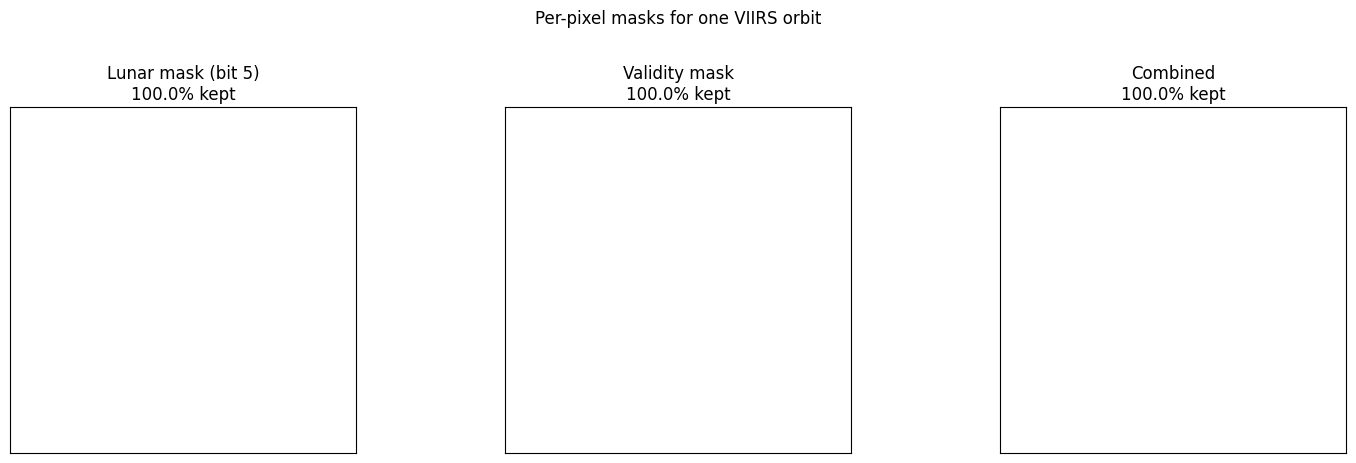

In [5]:
# Inspect the lunar bit. For VIIRS in this window, bit 5 should be set
# in roughly half the pixels (we're a few days before new moon).
zero_lunar_set = decode_bit(flag, VIIRS_ZERO_LUNAR_ILLUM_BIT)
pct = 100 * zero_lunar_set.mean()
print(f'VIIRS zero-lunar bit (bit 5) set in {pct:.1f}% of pixels')

# Show the three masks side by side.
cfg = SENSOR_CONFIGS[SENSOR_VIIRS]
lunar = make_lunar_mask(li, flag, cfg, mode='zero', low_thresh_lux=0.1)
validity = make_validity_mask(rad, li, cfg)
combined = lunar & validity

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mask, title in zip(
    axes,
    [lunar, validity, combined],
    [f'Lunar mask (bit 5)\n{100*lunar.mean():.1f}% kept',
     f'Validity mask\n{100*validity.mean():.1f}% kept',
     f'Combined\n{100*combined.mean():.1f}% kept'],
):
    ax.imshow(mask, cmap='gray_r')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Per-pixel masks for one VIIRS orbit', y=1.02)
plt.tight_layout(); plt.show()

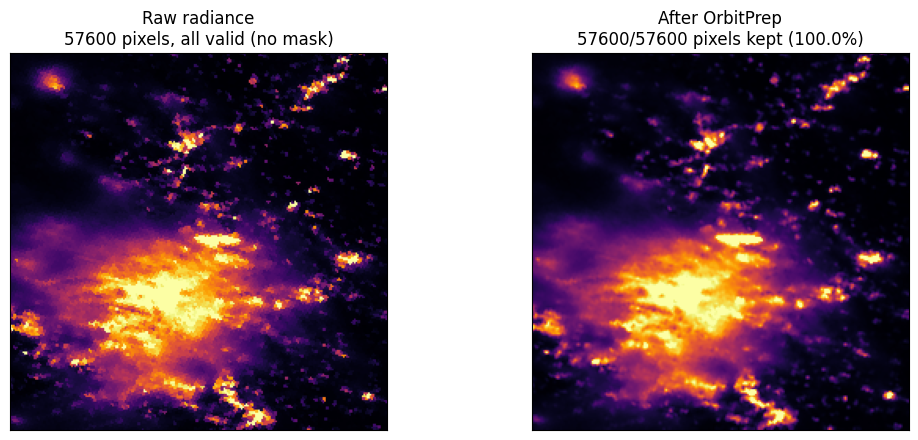

In [6]:
# Run the full OrbitPrep on one orbit and show before / after radiance.
prep = OrbitPrep(
    sensor=SENSOR_VIIRS,
    roi_bbox=PARIS_BBOX,
    dst_dir=TUTORIAL_CACHE / 'orbitprep',
    lunar_mask_mode='zero',
)
out = prep.transform({'orbit': orbit, 'radiance': paths['radiance'],
                      'li': paths['li'], 'flag': paths['flag']})

with rasterio.open(out['radiance']) as src:
    cleaned = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
vmax = np.nanquantile(cleaned[np.isfinite(cleaned)], 0.98) if np.isfinite(cleaned).any() else 1
axes[0].imshow(rad, cmap='inferno', vmin=0, vmax=vmax)
axes[0].set_title(f'Raw radiance\n{rad.size} pixels, all valid (no mask)')
axes[1].imshow(cleaned, cmap='inferno', vmin=0, vmax=vmax)
n_finite = int(np.isfinite(cleaned).sum())
axes[1].set_title(f'After OrbitPrep\n{n_finite}/{cleaned.size} pixels kept ({100*n_finite/cleaned.size:.1f}%)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Stage 3 — Compositing

**What it does.** Reduce all cleaned orbits within a *period* (default:
month) to a single per-pixel composite using a robust reducer.

**Math.** For period $P$ and pixel $p$:

$$
\hat{r}_{p,P} = \underset{t \in P : M_{p,t}=1}{\mathrm{median}} r_{p,t}
$$

with auxiliary outputs

$$
n_{p,P} = \sum_{t \in P} M_{p,t},
\qquad
\overline{\mathrm{LI}}_{p,P} = \frac{1}{n_{p,P}} \sum_{t \in P : M_{p,t}=1} \mathrm{LI}_{p,t}.
$$

**Why median?** Nightly imagery is contaminated by transient sources
the QA flags don't catch — fires, lightning, gas flares, undetected
cloud edges, aurora. The median is robust against ~50% asymmetric
outliers; the mean is not. The EOG-published composites use median
(or trimmed mean) for the same reason. The compositor accepts
`method="mean"` if smoother results are wanted.

**Why this is now "ours".** With nightly granules and QA layers in
hand, we control the compositing rules — including the lunar threshold,
extra QA bits, and aggregation period. The published EOG annual
composites baked these decisions in; we can vary them per experiment.

In [ ]:
# Pull a few days of orbits, run OrbitPrep on each, then composite.
viirs_records = ingest(
    PARIS_BBOX, WINDOW_START, WINDOW_END, SENSOR_VIIRS,
    cache_dir=TUTORIAL_CACHE / 'ingest',
)
print(f'ingested {len(viirs_records)} VIIRS orbits')

prep_v = OrbitPrep(SENSOR_VIIRS, PARIS_BBOX,
                   TUTORIAL_CACHE / 'orbitprep', lunar_mask_mode='zero')
viirs_prepped = [prep_v.transform(r) for r in viirs_records]

# Compositor reuses the OrbitPrep slug so its outputs land beside the
# matching prepped inputs in the cache.
viirs_comp = Compositor(
    SENSOR_VIIRS, TUTORIAL_CACHE / 'composite', roi_slug=prep_v.roi_slug,
).aggregate(viirs_prepped)
for c in viirs_comp:
    print(f'  composite period={c["period"]}: {c["n_orbits"]} orbits')


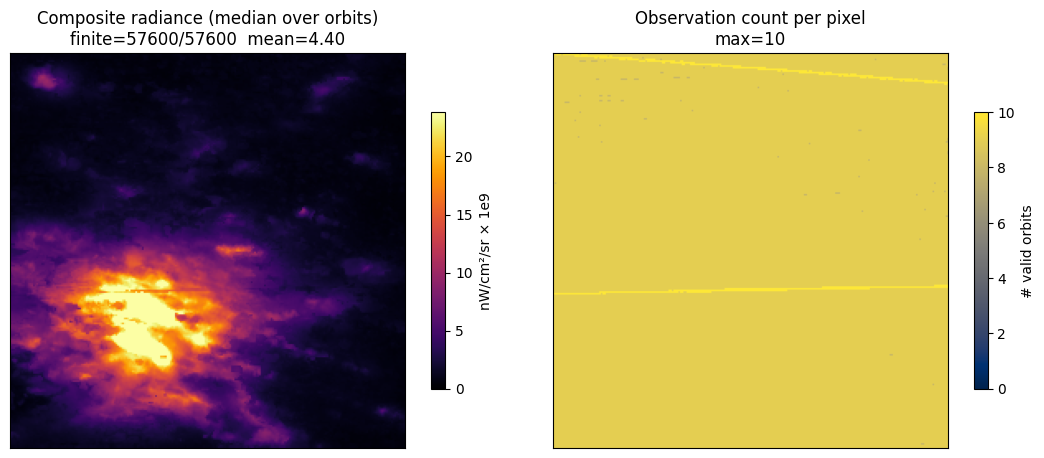

In [8]:
# Show the composite radiance + obs_count side by side.
with rasterio.open(viirs_comp[0]['radiance']) as src: comp_rad = src.read(1)
with rasterio.open(viirs_comp[0]['obs_count']) as src: comp_n = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
finite = comp_rad[np.isfinite(comp_rad)]
vmax = np.quantile(finite, 0.98) if finite.size else 1
im0 = axes[0].imshow(comp_rad, cmap='inferno', vmin=0, vmax=vmax)
axes[0].set_title(f'Composite radiance (median over orbits)\n'
                  f'finite={finite.size}/{comp_rad.size}  '
                  f'mean={np.nanmean(comp_rad):.2f}')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='nW/cm²/sr × 1e9')
im1 = axes[1].imshow(comp_n, cmap='cividis', vmin=0)
axes[1].set_title(f'Observation count per pixel\nmax={comp_n.max()}')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='# valid orbits')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. Stage 4a — DMSP intercalibration (Li 2017 stepwise)

**The problem.** DMSP-OLS isn't a calibrated radiometer. The same
physical scene produces different DN values across the F10–F18
satellites and across years on a single satellite (sensor degradation,
onboard amplification gain changes, orbital drift). Without
correction, what looks like "economic growth" in a raw DMSP series
is partly just sensor drift.

**Li et al. 2017 stepwise method.** Build a quadratic that maps each
satellite-year's composite onto a single reference satellite-year
(F16 2007). Coefficients are derived from regression in
*pseudo-invariant target* regions where ground brightness shouldn't
have changed (e.g. specific Sicily regions for European calibration):

$$
\widetilde{X} = c_0 + c_1 X + c_2 X^2
$$

with sat-year-specific $(c_0, c_1, c_2)$. The F16 era is treated as
two-step: first a within-F16 yearly correction (`F16A`), then a global
F16→reference correction (`F16B`). F10 and F12 fall outside the
published coefficient set; the codebase falls back to plain clipping
into `[0, 63]` for those years.

**Alternative.** Locally-derived coefs from the user's ROI would be
more accurate but add complexity. The published coefs are reasonable
global defaults and reproduce the legacy pipeline's behavior; the
codebase preserves room for a local derivation later.

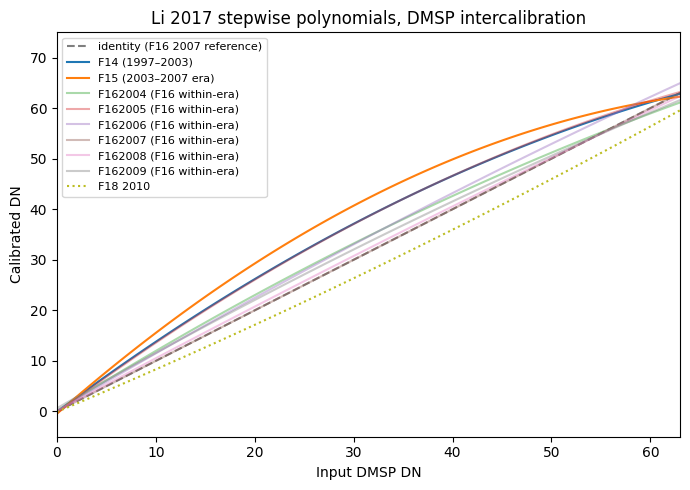

In [9]:
# Visualize each Li 2017 polynomial across the DMSP DN range [0, 63].
x = np.linspace(0, 63, 100)
fig, ax = plt.subplots(figsize=(7, 5))

def apply_poly(c, x): return c[0] + c[1]*x + c[2]*x**2

ax.plot(x, x, 'k--', label='identity (F16 2007 reference)', alpha=0.5)
ax.plot(x, apply_poly(PUBLISHED_COEFS['F14'], x), label='F14 (1997–2003)')
ax.plot(x, apply_poly(PUBLISHED_COEFS['F15'], x), label='F15 (2003–2007 era)')
for k, coef in sorted(PUBLISHED_COEFS['F16A'].items()):
    ax.plot(x, apply_poly(coef, x), alpha=0.4, label=f'{k} (F16 within-era)')
ax.plot(x, apply_poly(PUBLISHED_COEFS['F18'], x), label='F18 2010', linestyle=':')
ax.set_xlabel('Input DMSP DN'); ax.set_ylabel('Calibrated DN')
ax.set_title('Li 2017 stepwise polynomials, DMSP intercalibration')
ax.legend(loc='upper left', fontsize=8); ax.set_xlim(0, 63); ax.set_ylim(-5, 75)
plt.tight_layout(); plt.show()

## 8. Stage 4b — VIIRS preprocessing

**The problem.** VIIRS-DNB has a much wider dynamic range and finer
spatial resolution than DMSP-OLS, plus a stronger "blooming" response
to bright point sources (the latter is partly an artifact of the DNB
PSF and onboard processing). Feeding raw VIIRS into a regression
against DMSP would let bright pixels dominate and obscure the
dim-light end where DMSP has its real value.

**The recipe** (`harmonizer.transformers.viirsprep.VIIRSprep`):

1. **Damper.** Set $r \le \tau_d$ to zero (default $\tau_d = 1.0$
   nW·cm⁻²·sr⁻¹ × 10⁹). This is a noise-floor cut — DMSP saturates
   below ~0.5 DN, so anything below the threshold can't be matched anyway.
2. **Gaussian convolution** with a $(2\rho+1) \times (2\rho+1)$ kernel
   (default $\rho=5$, $\sigma=2$):

$$
k(i,j) = \frac{1}{Z}\exp\!\left(-\frac{i^2+j^2}{2\sigma^2}\right),
\qquad Z = \sum_{i,j} \exp\!\left(-\frac{i^2+j^2}{2\sigma^2}\right)
$$

    The convolution mimics DMSP's coarser PSF — without it, harmonizing
    a sharp VIIRS pixel against a blurred DMSP pixel just teaches the
    model to throw information away.
3. **`log1p` transform**, $f(r) = \ln(1 + r)$. Compresses the bright
    tail of the VIIRS distribution so the regression isn't dominated
    by gas flares and hyper-bright urban cores. `log1p` rather than
    `log` so zero stays zero.

In [ ]:
# Visualize the Gaussian kernel and the VIIRSprep effect.
kernel = get_kernel(pixelradius=5, sigma=2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im = axes[0].imshow(kernel, cmap='magma')
axes[0].set_title(f'Gaussian kernel (radius=5, σ=2)\nsum={kernel.sum():.3f}')
plt.colorbar(im, ax=axes[0], shrink=0.7)

# Apply VIIRSprep to the composite from stage 3.
viirs_pre = prep_viirs_composites(
    viirs_comp, TUTORIAL_CACHE / 'viirs_prepped', roi_slug=prep_v.roi_slug,
    usedask=False,
)
with rasterio.open(viirs_pre[0]['radiance']) as src: prepped = src.read(1)

vmax_raw = np.nanquantile(comp_rad[np.isfinite(comp_rad)], 0.98)
axes[1].imshow(comp_rad, cmap='inferno', vmin=0, vmax=vmax_raw)
axes[1].set_title(f'Composite radiance (raw)\nmax={np.nanmax(comp_rad):.1f}')
vmax_pre = np.nanquantile(prepped[np.isfinite(prepped)], 0.98)
axes[2].imshow(prepped, cmap='inferno', vmin=0, vmax=vmax_pre)
axes[2].set_title(f'After VIIRSprep (damper + Gaussian + log1p)\n'
                  f'max={np.nanmax(prepped):.2f}, mean={np.nanmean(prepped):.2f}')
for ax in axes[1:]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 9. Stage 5 — Harmonizer fit

**The setup.** With monthly composites for both sensors in 2013 (the
overlap year where DMSP F18 and VIIRS-NPP both operated), we have
paired pixels: VIIRS-prepped values $X$ and Li-calibrated DMSP DN
$y$. We fit a regression:

$$
\hat{y}_p = f(\mathbf{x}_p)
$$

where $\mathbf{x}_p$ can include polynomial expansions of the VIIRS
value and optional shifted-neighbor / index-grid features.

**Estimator choices** (`est=` in `Harmonizer`):
- `XGB()` — XGBoost regressor (default in `main.py`). Captures
  non-monotonic patterns where they exist.
- `CurveFit(degree=3)` — `sklearn` polynomial regression. Cheap,
  interpretable, good baseline.
- `NoFit()` — passthrough; useful for sanity-check ablations.

**Why train on overlap-year monthlies, not on the annual composite?**
12 paired frames means ~12× more training pixels per ROI, plus
intra-year variation (winter vs summer scene) gets baked into the
fit. The legacy pipeline's single-2013-annual-frame training was a
concession to the annual-only data layout, not a modelling choice.

**Resampling.** VIIRS native is 15 arc-sec; DMSP is 30 arc-sec.
Default behaviour resamples VIIRS down to the DMSP grid for fitting
and inference (`downsampleVIIRS=True`). The alternative — upsample
DMSP to VIIRS native — preserves VIIRS resolution but implies more
DMSP precision than actually exists; see the `harmonize.py`
docstring for the discussion.

**NaN handling.** Composites carry real NaN nodata. Training
row-filters: any pixel where either sensor's value is NaN is
dropped from the fit. Inference preserves NaN through the pipeline.

In [ ]:
# Build a quick paired DMSP+VIIRS month, then fit Harmonizer on it.
# (For a real run main.py trains on the full 2013 monthly stack;
# here we just want to demonstrate the fit/transform shape.)

PREFERRED_SATS = {'F18': ['2013']}  # F18 covers 2013 in the legacy table
dmsp_records = ingest(
    PARIS_BBOX, WINDOW_START, WINDOW_END, SENSOR_DMSP,
    cache_dir=TUTORIAL_CACHE / 'ingest',
    dmsp_preferred_sats=PREFERRED_SATS,
)
print(f'ingested {len(dmsp_records)} DMSP orbits')

prep_d = OrbitPrep(SENSOR_DMSP, PARIS_BBOX,
                   TUTORIAL_CACHE / 'orbitprep', lunar_mask_mode='zero')
dmsp_prepped = [prep_d.transform(r) for r in dmsp_records]
dmsp_comp = Compositor(
    SENSOR_DMSP, TUTORIAL_CACHE / 'composite', roi_slug=prep_d.roi_slug,
).aggregate(dmsp_prepped)
dmsp_calib = calibrate_dmsp_composites(
    dmsp_comp, TUTORIAL_CACHE / 'calib', PREFERRED_SATS, roi_slug=prep_d.roi_slug,
)

train_periods = sorted(
    {c['period'] for c in dmsp_calib} & {c['period'] for c in viirs_pre}
)
print(f'training periods (DMSP ∩ VIIRS): {train_periods}')

harmonized_dir = TUTORIAL_CACHE / 'harmonized'
h = Harmonizer(
    dmsp_period_dir=TUTORIAL_CACHE / 'calib' / prep_d.roi_slug,
    viirs_period_dir=TUTORIAL_CACHE / 'viirs_prepped' / prep_v.roi_slug,
    output_dir=harmonized_dir,
    train_periods=train_periods,
    est=CurveFit(degree=3),
    polyX=False,  # CurveFit does its own polynomial expansion
)
h.fit()


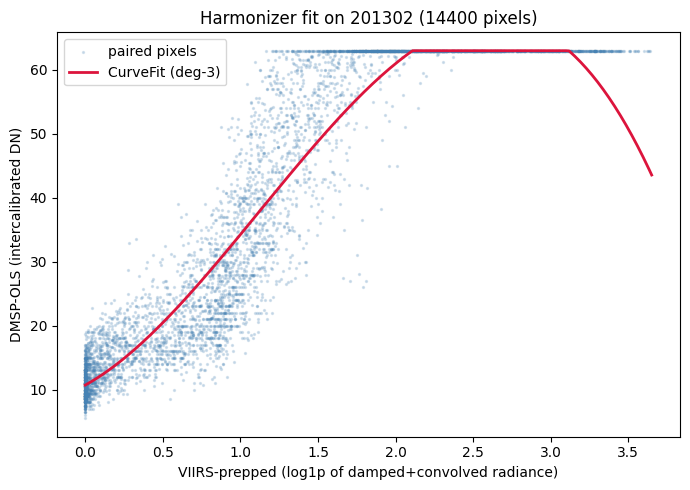

In [12]:
# Show what the fit learned: scatter of paired pixels + the fitted curve.
viirs_arr, dmsp_arr, _ = h._read_aligned_pair(train_periods[0])
valid = np.isfinite(viirs_arr) & np.isfinite(dmsp_arr)
x = viirs_arr[valid]
y = dmsp_arr[valid]

x_grid = np.linspace(x.min(), x.max(), 200)
X_grid, _ = h.Xy_transform(x_grid.reshape(-1, 1).astype(np.float32))
y_grid = h.est.predict(X_grid)

fig, ax = plt.subplots(figsize=(7, 5))
# Subsample for plotting; alpha to see density.
idx = np.random.choice(x.size, size=min(5000, x.size), replace=False)
ax.scatter(x[idx], y[idx], s=2, alpha=0.2, color='steelblue', label='paired pixels')
ax.plot(x_grid, np.clip(y_grid, 0, 63), color='crimson', linewidth=2, label='CurveFit (deg-3)')
ax.set_xlabel('VIIRS-prepped (log1p of damped+convolved radiance)')
ax.set_ylabel('DMSP-OLS (intercalibrated DN)')
ax.set_title(f'Harmonizer fit on {train_periods[0]} ({x.size} pixels)')
ax.legend()
plt.tight_layout(); plt.show()

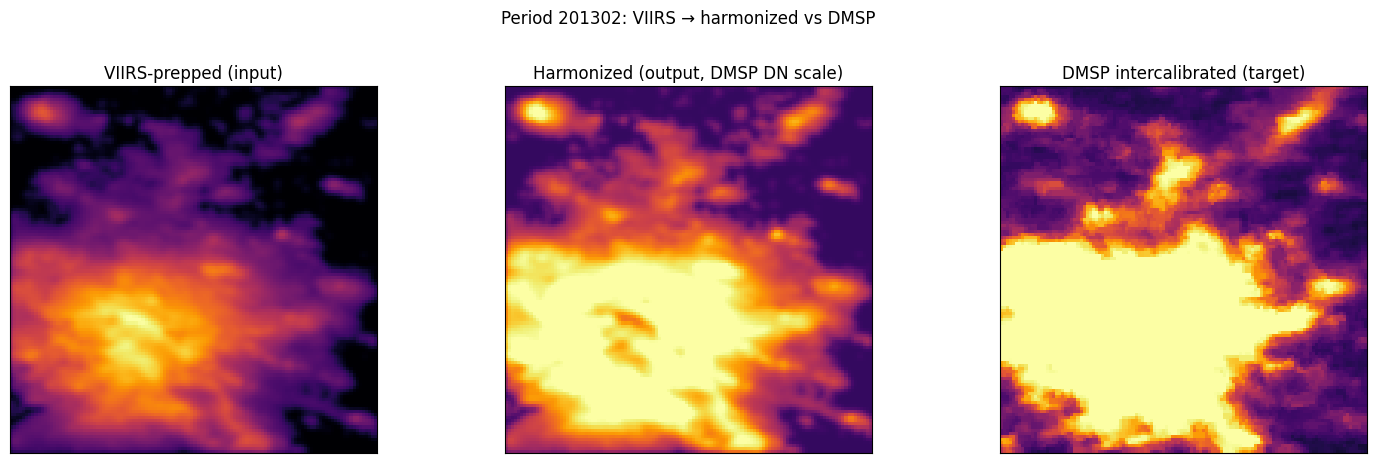

pixelwise RMSD between harmonized VIIRS and intercalibrated DMSP: 6.437 DN


In [13]:
# Apply the fit to a period and inspect the output.
out_path = h.transform(train_periods[0])
with rasterio.open(out_path) as src: harmonized = src.read(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmax = np.nanquantile(np.concatenate([
    dmsp_arr[np.isfinite(dmsp_arr)],
    harmonized[np.isfinite(harmonized)],
]), 0.98)
axes[0].imshow(viirs_arr, cmap='inferno')
axes[0].set_title(f'VIIRS-prepped (input)')
axes[1].imshow(harmonized, cmap='inferno', vmin=0, vmax=vmax)
axes[1].set_title(f'Harmonized (output, DMSP DN scale)')
axes[2].imshow(dmsp_arr, cmap='inferno', vmin=0, vmax=vmax)
axes[2].set_title(f'DMSP intercalibrated (target)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Period {train_periods[0]}: VIIRS → harmonized vs DMSP', y=1.02)
plt.tight_layout(); plt.show()

# Quick metric: pixelwise RMSD.
valid_h = np.isfinite(harmonized) & np.isfinite(dmsp_arr)
rmsd = float(np.sqrt(np.mean((harmonized[valid_h] - dmsp_arr[valid_h])**2)))
print(f'pixelwise RMSD between harmonized VIIRS and intercalibrated DMSP: {rmsd:.3f} DN')

## 10. End-to-end use case

Everything above is what `python -m harmonizer.main` strings together.
On a real ROI (e.g. a country shapefile) over a multi-year date range,
it produces:

- `output/<trial>/<period>/radiance.tif` — one harmonized DN raster per
  inference period, on the DMSP 30-arc-sec grid.
- `artifacts/<trial>_harmonizer.dill` — the trained model.
- `results/<trial>/` — diagnostic plots (per-training-period scatter +
  hist; full-series mean/median/sum time series) plus a
  `training_metrics.txt` with RMSD + Spearman R per training period.

**A reasonable use case.** Track regional economic activity across
France over 2012–2013 — a window straddling the late eurozone
sovereign-debt downturn, France's January 2012 loss of its AAA rating,
and the early recovery. 2012 is DMSP-only (F18) and 2013 is the
DMSP/VIIRS overlap year. The harmonized series lets us compute
year-over-year mean DN inside NUTS-3 admin polygons on a single
comparable scale, suitable for regression against regional GDP,
employment, or unemployment series. The same fit extends back to 1992
on DMSP and forward to the present on VIIRS once it is trained on the
overlap year.

**Caveats to keep in mind.**
1. **Pixel-DN is not a calibrated radiance** — it's a regression
   target. Use it for relative changes within the harmonized series,
   not as a physical quantity.
2. **Saturation** at DN=63 over urban cores limits sensitivity to
   change in already-bright pixels. Some studies switch to `log(1+DN)`
   or use VIIRS native radiance for urban-only analysis.
3. **Coverage gaps** — F10/F12 (1992–1996) currently emit clip-only
   output (no published Li 2017 coefs). For applications that need
   the early DMSP era, consider deriving local coefficients from
   pseudo-invariant targets in your ROI.
4. **Lunar mask choice matters.** `mode="zero"` reproduces the
   EOG composites' convention but discards information. For dim-light
   detection in regions far from the lunar terminator, `"low"` with a
   small threshold may be preferable. The pipeline supports
   stratified harmonization (separate models per lunar regime) — see
   the planning doc in the repo.

**To reproduce the country-scale run analyzed below:**

```sh
python -m harmonizer.main \
    -n france_2012_2013 \
    --roi roifiles/gadm36_FRA_shp/gadm36_FRA_0.shp \
    --start 2012-04-01 --end 2013-12-31 \
    --train-year 2013 --lunar-mode zero
```

Wall-clock is dominated by the network-bound ingest stage. With the
concurrent COG reader (`max_workers=32` by default) and a warm cache
France 2012–2013 finishes in roughly an hour; cold-start time scales
with the underlying S3 throughput.

---


## 11. Inspecting the trial outputs

The country-scale run drops three classes of artifacts in
`results/<trial>/`:

- **Per-training-period diagnostics** — `<period>_scatter.png` and
  `<period>_hist.png`. The scatter shows harmonized VIIRS DN vs the
  Li-calibrated DMSP target across the ROI's valid pixels for one
  training period; the histogram pair shows the marginal distributions
  on the two scales. Tighter clouds and well-overlapping histograms
  mean the fit transferred VIIRS onto the DMSP scale cleanly.
- **Time-series summaries** — `harmonized_ts_{mean,median,sum}.png`.
  ROI-wide reductions across every inference period. The most
  important sanity check is *continuity at the DMSP→VIIRS boundary*:
  if the regression generalized, the line should not jog at the handoff
  month.
- **Headline metrics** — `training_metrics.txt` with per-training-period
  RMSD (DN units) and Spearman R between harmonized VIIRS and the DMSP
  target inside the ROI.

The cells below load whatever exists for `france_2012_2013`. If the
trial is still in flight, missing artifacts are reported and skipped —
re-run the cells once the pipeline completes to populate them.

In [ ]:
# Setup. Resolve the trial's artifact directories and define a small
# helper that displays a saved PNG inline, or reports it missing if the
# pipeline hasn't produced it yet (lets the cells below run end-to-end
# regardless of trial state).
import os
from pathlib import Path
from IPython.display import Image, display

TRIAL = "france_2012_2013"
NLT_ROOT = Path(os.environ.get("NLT", "/home/daynan/resonance"), "NTL_Harmonizer")
RESULTS_DIR = NLT_ROOT / "results" / TRIAL
OUTPUT_DIR  = NLT_ROOT / "output"  / TRIAL
ARTIFACT    = NLT_ROOT / "artifacts" / f"{TRIAL}_harmonizer.dill"

print(f"results dir : {RESULTS_DIR}  (exists={RESULTS_DIR.exists()})")
print(f"output  dir : {OUTPUT_DIR}   (exists={OUTPUT_DIR.exists()})")
print(f"model       : {ARTIFACT}     (exists={ARTIFACT.exists()})")

def show_if(path, label=None):
    p = Path(path)
    if not p.exists():
        print(f"[missing] {label or p.name}")
        return False
    print(f"[ok] {label or p.name}")
    display(Image(filename=str(p)))
    return True


In [ ]:
# Headline numbers: per-training-period RMSD and Spearman R across the
# ROI's valid pixels. RMSD is in DN units (DMSP scale, 0–63); Spearman R
# captures rank-order agreement (less sensitive to scale calibration than
# Pearson, more relevant for downstream "which areas are brighter" use).
metrics_txt = RESULTS_DIR / "training_metrics.txt"
if metrics_txt.exists():
    print(metrics_txt.read_text())
else:
    print(f"[missing] {metrics_txt} — pipeline still running?")


In [ ]:
# Per-training-period diagnostics: harmonized vs DMSP scatter and the
# marginal distribution pair. The scatter is the visual analogue of the
# RMSD / Spearman R numbers reported in training_metrics.txt above —
# tighter clouds on y=x mean a better fit, fan-out at high DN means the
# regression is missing structure in the bright tail.
scatter_paths = sorted(RESULTS_DIR.glob("*_scatter.png"))
hist_paths    = sorted(RESULTS_DIR.glob("*_hist.png"))
if not scatter_paths and not hist_paths:
    print(f"[missing] no per-period scatter/hist diagnostics in {RESULTS_DIR}")
for p in scatter_paths:
    show_if(p, label=f"scatter {p.stem}")
for p in hist_paths:
    show_if(p, label=f"hist {p.stem}")


In [ ]:
# ROI-wide time-series reductions across every inference period.
# These are the headline "is the cross-platform handoff smooth?" plots:
# the DMSP era (2012) and the VIIRS era (2013) should connect without
# a visible step at the boundary.
for stat in ("mean", "median", "sum"):
    show_if(RESULTS_DIR / f"harmonized_ts_{stat}.png", label=f"ROI {stat} time series")


In [ ]:
# Sample harmonized raster from the middle of the inference period.
import numpy as np
import matplotlib.pyplot as plt
import rasterio

period_dirs = sorted([p for p in OUTPUT_DIR.glob("*") if p.is_dir()])
if not period_dirs:
    print(f"[missing] no per-period output directories under {OUTPUT_DIR}")
else:
    sample = period_dirs[len(period_dirs) // 2]
    rad_path = sample / "radiance.tif"
    if not rad_path.exists():
        print(f"[missing] {rad_path}")
    else:
        with rasterio.open(rad_path) as src:
            harm = src.read(1).astype(float)
        # Treat zeros as masked for display contrast (common in DMSP-DN outputs).
        finite = np.isfinite(harm) & (harm > 0)
        vmax = float(np.quantile(harm[finite], 0.99)) if finite.any() else 1.0
        fig, ax = plt.subplots(figsize=(7, 7))
        im = ax.imshow(harm, cmap="inferno", vmin=0, vmax=vmax)
        ax.set_title(f"Harmonized output — period {sample.name}\n"
                     f"(DN scale, DMSP 30 arc-sec grid; non-zero pixels: {int(finite.sum()):,})")
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.04, label="harmonized DN")
        plt.tight_layout(); plt.show()


## 12. References

**Foundational NTL applications**
- Henderson, J.V., Storeygard, A., Weil, D.N. 2012. *Measuring Economic
  Growth from Outer Space.* American Economic Review 102(2): 994–1028.
- Min, B., Gaba, K.M., Sarr, O.F., Agalassou, A. 2013. *Detection of
  rural electrification in Africa using DMSP-OLS night lights imagery.*
  International Journal of Remote Sensing 34(22): 8118–8141.

**Sensor characterization**
- Elvidge, C.D., Baugh, K.E., Zhizhin, M., Hsu, F.-C., Ghosh, T. 2017.
  *VIIRS Night-time Lights.* International Journal of Remote Sensing
  38(21): 5860–5879.
- Mills, S., Weiss, S., Liang, C. 2013. *VIIRS day/night band stray
  light characterization and correction.* SPIE 8866.
- Román, M.O., et al. 2018. *NASA's Black Marble nighttime lights
  product suite.* Remote Sensing of Environment 210: 113–143.

**DMSP intercalibration (the recipe in `dmspcalibrate.py`)**
- Li, X., Zhao, L., Li, D., Xu, H. 2017. *An Improved Stepwise
  Calibration of DMSP-OLS Stable Nighttime Light Data.* Remote Sensing
  9(6): 637. https://www.mdpi.com/2072-4292/9/6/637

**Data archive**
- World Bank Light Every Night dataset:
  https://registry.opendata.aws/wb-light-every-night/
- World Bank *Open Nighttime Lights* tutorial:
  https://worldbank.github.io/OpenNightLights/

**This repo**
- See `README.md` for the full pipeline description and CLI usage.
- See `NTL_Harmonizer_Clay_Integration_Plan.md` for the longer roadmap
  (Clay foundation-model conditioning, lunar-stratified harmonization,
  metadata-feature ablations).